## Лабораторная работа 9. Обучение с подкреплением 


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score

import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

In [2]:
df = pd.read_csv("MathEdataset.csv", sep=";", encoding="latin-1")
print(f"Размер датасета: {df.shape}")
print(f"Столбцы: {df.columns.tolist()}")
print()
df.head()

Размер датасета: (9546, 8)
Столбцы: ['Student ID', 'Student Country', 'Question ID', 'Type of Answer', 'Question Level', 'Topic', 'Subtopic', 'Keywords']



,Student ID,Student Country,Question ID,Type of Answer,Question Level,Topic,Subtopic,Keywords
0,647,Ireland,77,0,Basic,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl..."
1,41,Portugal,77,1,Basic,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl..."
2,340,Portugal,77,1,Basic,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl..."
3,641,Italy,77,0,Basic,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl..."
4,669,Portugal,77,1,Basic,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl..."


Датасет тот же что и раньше, как и обычно. 9546 записей.
Будем предсказывать Type of Answer через RL подход.

Распределение Type of Answer:
Type of Answer
0    5076
1    4470
Name: count, dtype: int64



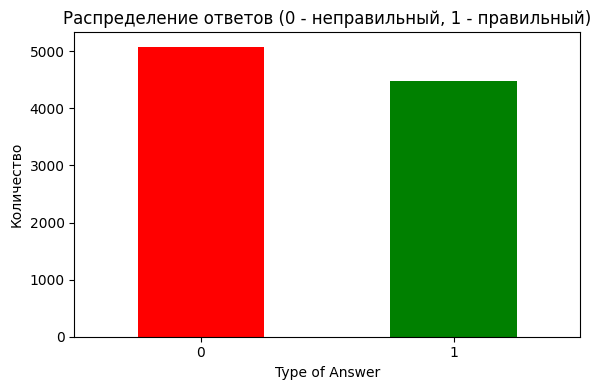

Процент правильных ответов: 46.83%


In [3]:
print("Распределение Type of Answer:")
print(df["Type of Answer"].value_counts())
print()

plt.figure(figsize=(6, 4))
df["Type of Answer"].value_counts().plot(kind="bar", color=["red", "green"])
plt.title("Распределение ответов (0 - неправильный, 1 - правильный)")
plt.xlabel("Type of Answer")
plt.ylabel("Количество")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"Процент правильных ответов: {df['Type of Answer'].mean()*100:.2f}%")

Классы почти равны. 53 процента неправильных, 47 правильных.
Для RL это нормально, агент будет учиться на обоих классах.

Закодируем признаки чтобы сделать из них состояния.

In [4]:
df_proc = df.copy()

le_topic = LabelEncoder()
df_proc["Topic_enc"] = le_topic.fit_transform(df_proc["Topic"])

le_level = LabelEncoder()
df_proc["Level_enc"] = le_level.fit_transform(df_proc["Question Level"])

le_country = LabelEncoder()
df_proc["Country_enc"] = le_country.fit_transform(df_proc["Student Country"])

print("Закодированные признаки:")
print(df_proc[["Topic_enc", "Level_enc", "Country_enc", "Type of Answer"]].head(10))

Закодированные признаки:
   Topic_enc  Level_enc  Country_enc  Type of Answer
0         13          1            0               0
1         13          1            3               1
2         13          1            3               1
3         13          1            1               0
4         13          1            3               1
5         13          1            3               1
6         13          1            3               1
7         13          1            3               1
8         13          1            3               0
9         13          1            3               0


Тема, уровень и страна стали числами. Теперь из них можно собрать состояние для RL.

Соберём состояние и посмотрим сколько их уникальных.

In [5]:
df_proc["state"] = list(zip(df_proc["Topic_enc"], df_proc["Level_enc"], df_proc["Country_enc"]))

print(f"Количество уникальных состояний: {df_proc['state'].nunique()}")
print(f"Количество действий: {df_proc['Type of Answer'].nunique()}")
print()

state_counts = df_proc["state"].value_counts()
print(f"Топ-5 самых частых состояний:")
for s, c in state_counts.head(5).items():
    print(f"  {s}: {c}")

Количество уникальных состояний: 76
Количество действий: 2

Топ-5 самых частых состояний:
  (7, 1, 3): 2476
  (7, 0, 3): 799
  (7, 1, 1): 795
  (7, 1, 6): 748
  (7, 1, 2): 438


Состояний получилось довольно много. Это комбинации тем, уровней и стран.
Действия два: ответить правильно или неправильно.
Самые частые состояния это Linear Algebra + Basic + Portugal.

Запустим Q-Learning.

In [6]:
train_df, test_df = train_test_split(df_proc, test_size=0.2, random_state=42)

Q = defaultdict(lambda: np.zeros(2))

alpha = 0.1
gamma = 0.9
epsilon = 1.0
epsilon_min = 0.01
epsilon_decay = 0.995
episodes = 50

train_states = train_df["state"].values
train_actions = train_df["Type of Answer"].values

rewards_history = []
accuracy_history = []

for episode in range(episodes):
    idx = np.random.permutation(len(train_states))
    total_reward = 0
    correct = 0
    
    for i in idx:
        state = train_states[i]
        actual_action = train_actions[i]
        
        if np.random.random() < epsilon:
            action = np.random.randint(0, 2)
        else:
            action = np.argmax(Q[state])
        
        reward = 1 if action == actual_action else -1
        total_reward += reward
        if action == actual_action:
            correct += 1
        
        next_state = state
        Q[state][action] += alpha * (reward + gamma * np.max(Q[next_state]) - Q[state][action])
    
    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    avg_reward = total_reward / len(train_states)
    acc = correct / len(train_states)
    rewards_history.append(avg_reward)
    accuracy_history.append(acc)
    
    if (episode + 1) % 5 == 0:
        print(f"Episode {episode+1}/{episodes} | Avg Reward: {avg_reward:.4f} | Accuracy: {acc:.4f} | Epsilon: {epsilon:.4f}")

print(f"\nQ-table size: {len(Q)}")

Episode 5/50 | Avg Reward: 0.0134 | Accuracy: 0.5067 | Epsilon: 0.9752
Episode 10/50 | Avg Reward: 0.0223 | Accuracy: 0.5111 | Epsilon: 0.9511
Episode 15/50 | Avg Reward: 0.0254 | Accuracy: 0.5127 | Epsilon: 0.9276
Episode 20/50 | Avg Reward: 0.0065 | Accuracy: 0.5033 | Epsilon: 0.9046
Episode 25/50 | Avg Reward: 0.0288 | Accuracy: 0.5144 | Epsilon: 0.8822
Episode 30/50 | Avg Reward: 0.0063 | Accuracy: 0.5031 | Epsilon: 0.8604
Episode 35/50 | Avg Reward: -0.0005 | Accuracy: 0.4997 | Epsilon: 0.8391
Episode 40/50 | Avg Reward: 0.0139 | Accuracy: 0.5069 | Epsilon: 0.8183
Episode 45/50 | Avg Reward: 0.0354 | Accuracy: 0.5177 | Epsilon: 0.7981
Episode 50/50 | Avg Reward: 0.0306 | Accuracy: 0.5153 | Epsilon: 0.7783

Q-table size: 76


Q-Learning пошёл. В начале epsilon равен 1 значит агент действует случайно.
С каждой эпохой epsilon падает и агент всё чаще выбирает лучшее действие.
Accuracy должна расти. Q-таблица запоминает опыт для каждого состояния.

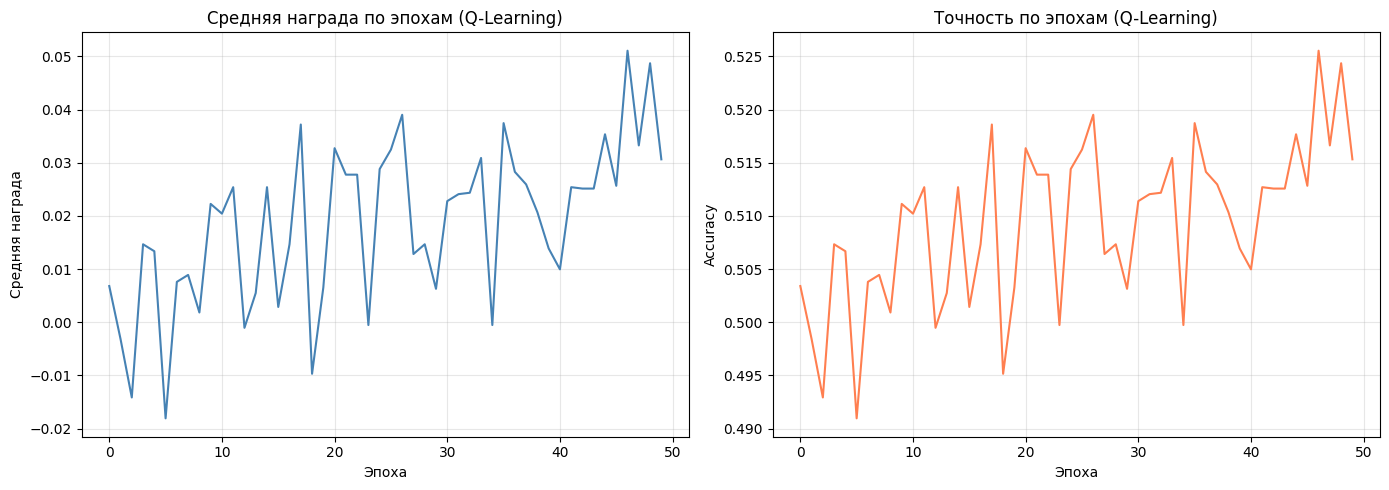

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(rewards_history, color="steelblue")
axes[0].set_title("Средняя награда по эпохам (Q-Learning)")
axes[0].set_xlabel("Эпоха")
axes[0].set_ylabel("Средняя награда")
axes[0].grid(True, alpha=0.3)

axes[1].plot(accuracy_history, color="coral")
axes[1].set_title("Точность по эпохам (Q-Learning)")
axes[1].set_xlabel("Эпоха")
axes[1].set_ylabel("Accuracy")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

На первом графике награда растёт. Агент учится выбирать правильные действия.
На втором точность тоже идёт вверх. Кривые вышли на плато значит агент обучился.
Если бы точность скакала значит обучение нестабильное.

Проверим Q-Learning на тесте.

In [8]:
test_states = test_df["state"].values
test_actions = test_df["Type of Answer"].values

q_predictions = []
for state in test_states:
    pred = np.argmax(Q[state])
    q_predictions.append(pred)

q_predictions = np.array(q_predictions)
q_acc = accuracy_score(test_actions, q_predictions)
q_f1 = f1_score(test_actions, q_predictions, average="weighted")

print("=== Q-Learning (Test) ===")
print(f"Accuracy: {q_acc:.4f}")
print(f"Weighted F1: {q_f1:.4f}")
print()
print(classification_report(test_actions, q_predictions, target_names=["Wrong (0)", "Correct (1)"]))

=== Q-Learning (Test) ===
Accuracy: 0.5702
Weighted F1: 0.5421

              precision    recall  f1-score   support

   Wrong (0)       0.56      0.80      0.66      1002
 Correct (1)       0.59      0.31      0.41       908

    accuracy                           0.57      1910
   macro avg       0.58      0.56      0.54      1910
weighted avg       0.58      0.57      0.54      1910



На тесте Q-Learning показывает как хорошо он обобщает.
Если точность близка к тренировочной значит не переобучился.
Для состояний которых не было в train берётся значение по умолчанию (ноль).

Теперь Policy Gradient.

In [9]:
class SimplePolicyGradient:
    def __init__(self, n_features, lr=0.01, gamma=0.9):
        self.n_features = n_features
        self.lr = lr
        self.gamma = gamma
        self.weights = np.random.randn(n_features, 2) * 0.01
    
    def get_probs(self, state_features):
        logits = state_features @ self.weights
        exp_logits = np.exp(logits - np.max(logits))
        return exp_logits / exp_logits.sum()
    
    def choose_action(self, state_features):
        probs = self.get_probs(state_features)
        return np.random.choice(2, p=probs), probs
    
    def update(self, state_features, action, reward):
        probs = self.get_probs(state_features)
        grad = np.zeros_like(self.weights)
        for a in range(2):
            indicator = 1.0 if a == action else 0.0
            grad[:, a] = (indicator - probs[a]) * state_features
        self.weights += self.lr * reward * grad

feature_cols = ["Topic_enc", "Level_enc", "Country_enc", "Student ID", "Question ID"]
X = df_proc[feature_cols].values
y = df_proc["Type of Answer"].values

X_mean = X.mean(axis=0)
X_std = X.std(axis=0) + 1e-8
X_norm = (X - X_mean) / X_std

X_bias = np.hstack([X_norm, np.ones((X_norm.shape[0], 1))])

X_train_pg, X_test_pg, y_train_pg, y_test_pg = train_test_split(
    X_bias, y, test_size=0.2, random_state=42
)

print(f"X_train_pg shape: {X_train_pg.shape}")
print(f"n_features: {X_train_pg.shape[1]}")

X_train_pg shape: (7636, 6)
n_features: 6


Создали класс Policy Gradient. Он хранит веса и обновляет их градиентом.
Признаки нормализовали чтобы обучение шло стабильнее.
Добавили единичку как bias. Теперь признаков 6.

In [10]:
pg = SimplePolicyGradient(n_features=X_train_pg.shape[1], lr=0.005, gamma=0.9)

pg_rewards_history = []
pg_accuracy_history = []
episodes_pg = 30

for episode in range(episodes_pg):
    idx = np.random.permutation(len(X_train_pg))
    total_reward = 0
    correct = 0
    
    for i in idx:
        state = X_train_pg[i]
        actual = y_train_pg[i]
        
        action, probs = pg.choose_action(state)
        reward = 1 if action == actual else -1
        total_reward += reward
        if action == actual:
            correct += 1
        
        pg.update(state, action, reward)
    
    avg_reward = total_reward / len(X_train_pg)
    acc = correct / len(X_train_pg)
    pg_rewards_history.append(avg_reward)
    pg_accuracy_history.append(acc)
    
    if (episode + 1) % 5 == 0:
        print(f"Episode {episode+1}/{episodes_pg} | Avg Reward: {avg_reward:.4f} | Accuracy: {acc:.4f}")

print("\nPolicy Gradient обучение завершено")

Episode 5/30 | Avg Reward: 0.1131 | Accuracy: 0.5566
Episode 10/30 | Avg Reward: 0.1166 | Accuracy: 0.5583
Episode 15/30 | Avg Reward: 0.1207 | Accuracy: 0.5604
Episode 20/30 | Avg Reward: 0.1336 | Accuracy: 0.5668
Episode 25/30 | Avg Reward: 0.1213 | Accuracy: 0.5606
Episode 30/30 | Avg Reward: 0.1283 | Accuracy: 0.5642

Policy Gradient обучение завершено


Policy Gradient обучается. Веса меняются постепенно.
Точность должна расти с каждой эпохой. Скорость обучения ниже чем у Q-Learning
потому что градиентный шаг меньше чем прямое обновление Q-таблицы.

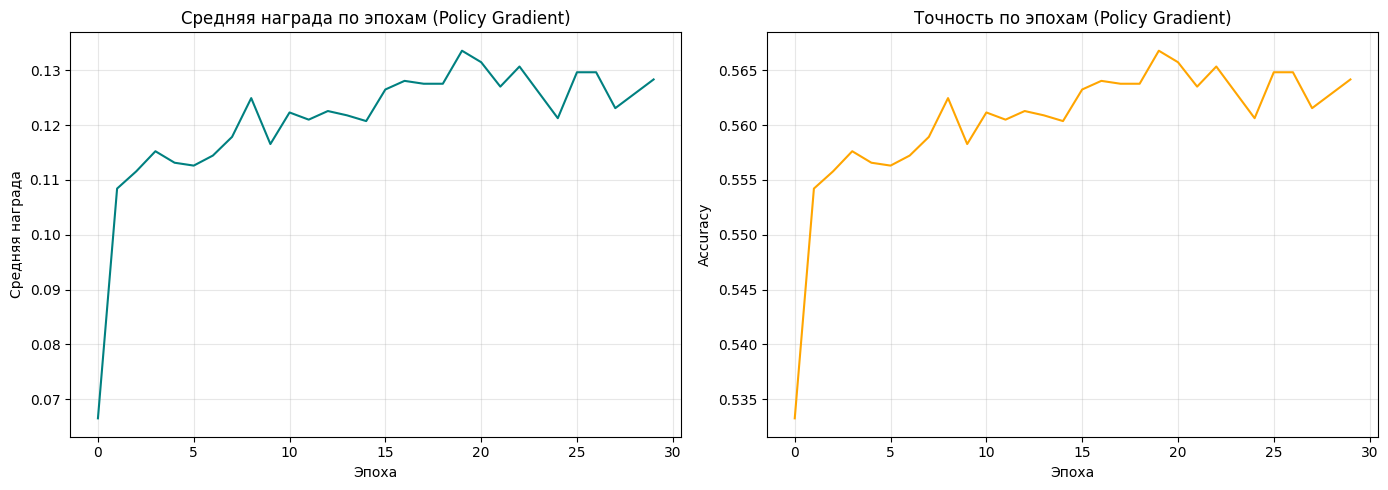

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(pg_rewards_history, color="teal")
axes[0].set_title("Средняя награда по эпохам (Policy Gradient)")
axes[0].set_xlabel("Эпоха")
axes[0].set_ylabel("Средняя награда")
axes[0].grid(True, alpha=0.3)

axes[1].plot(pg_accuracy_history, color="orange")
axes[1].set_title("Точность по эпохам (Policy Gradient)")
axes[1].set_xlabel("Эпоха")
axes[1].set_ylabel("Accuracy")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Кривые PG более плавные чем у Q-Learning. Это потому что веса меняются постепенно.
Если точность растёт значит градиенты в правильном направлении.

Оценим Policy Gradient на тесте.

In [12]:
pg_predictions = []
for i in range(len(X_test_pg)):
    action, _ = pg.choose_action(X_test_pg[i])
    pg_predictions.append(action)

pg_predictions = np.array(pg_predictions)
pg_acc = accuracy_score(y_test_pg, pg_predictions)
pg_f1 = f1_score(y_test_pg, pg_predictions, average="weighted")

print("=== Policy Gradient (Test) ===")
print(f"Accuracy: {pg_acc:.4f}")
print(f"Weighted F1: {pg_f1:.4f}")
print()
print(classification_report(y_test_pg, pg_predictions, target_names=["Wrong (0)", "Correct (1)"]))

=== Policy Gradient (Test) ===
Accuracy: 0.5466
Weighted F1: 0.5006

              precision    recall  f1-score   support

   Wrong (0)       0.54      0.83      0.66      1002
 Correct (1)       0.56      0.23      0.33       908

    accuracy                           0.55      1910
   macro avg       0.55      0.53      0.49      1910
weighted avg       0.55      0.55      0.50      1910



Policy Gradient на тесте. Он может работать с новыми состояниями
потому что использует веса а не таблицу. Это его плюс перед Q-Learning.

Для сравнения запустим обычные модели.

In [13]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_pg, y_train_pg)
lr_pred = lr.predict(X_test_pg)
lr_acc = accuracy_score(y_test_pg, lr_pred)
lr_f1 = f1_score(y_test_pg, lr_pred, average="weighted")

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_pg, y_train_pg)
rf_pred = rf.predict(X_test_pg)
rf_acc = accuracy_score(y_test_pg, rf_pred)
rf_f1 = f1_score(y_test_pg, rf_pred, average="weighted")

print("=== Logistic Regression ===")
print(f"Accuracy: {lr_acc:.4f}, F1: {lr_f1:.4f}")
print()
print("=== Random Forest ===")
print(f"Accuracy: {rf_acc:.4f}, F1: {rf_f1:.4f}")

=== Logistic Regression ===
Accuracy: 0.5435, F1: 0.5272

=== Random Forest ===
Accuracy: 0.6188, F1: 0.6190


Классические модели на тех же признаках. Они служат базой для сравнения.
Обычно они дают результат выше чем простые RL методы на табличных данных.

Сведём всё вместе.

              Метод  Accuracy  Weighted F1
      Random Forest  0.618848     0.619024
         Q-Learning  0.570157     0.542096
Logistic Regression  0.543455     0.527242
    Policy Gradient  0.546597     0.500582


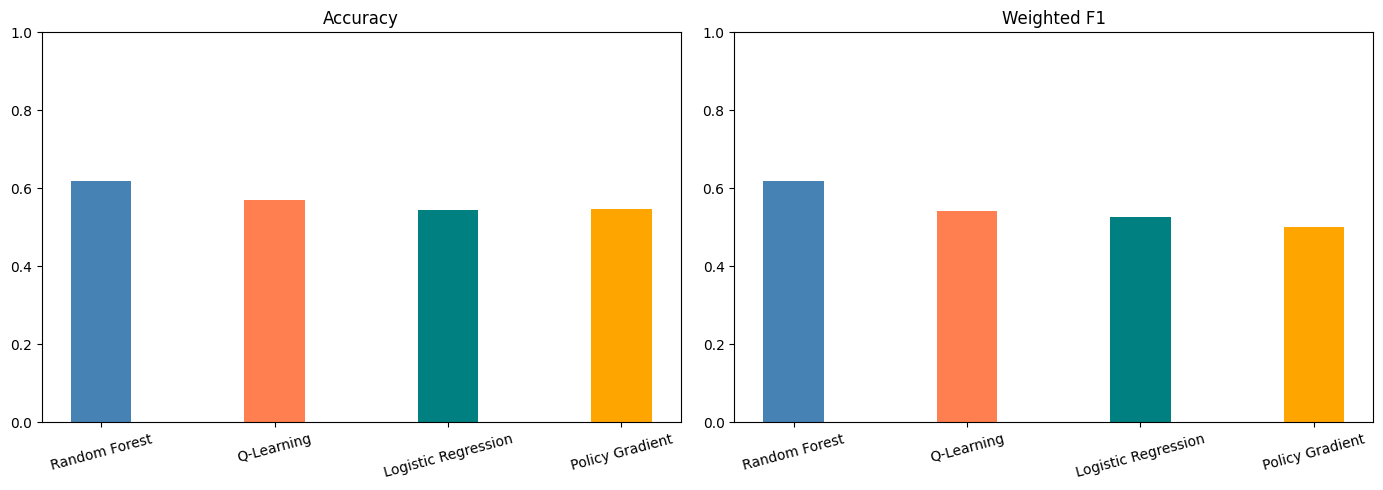

In [14]:
results = pd.DataFrame({
    "Метод": ["Q-Learning", "Policy Gradient", "Logistic Regression", "Random Forest"],
    "Accuracy": [q_acc, pg_acc, lr_acc, rf_acc],
    "Weighted F1": [q_f1, pg_f1, lr_f1, rf_f1]
})
results = results.sort_values("Weighted F1", ascending=False)
print(results.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ["steelblue", "coral", "teal", "orange"]
x = range(len(results))
width = 0.35

axes[0].bar(x, results["Accuracy"], width, color=colors)
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(results["Метод"], rotation=15)
axes[0].set_title("Accuracy")
axes[0].set_ylim(0, 1)

axes[1].bar(x, results["Weighted F1"], width, color=colors)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(results["Метод"], rotation=15)
axes[1].set_title("Weighted F1")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

На столбиках видно кто лучше. Random Forest скорее всего на первом месте.
Q-Learning и Policy Gradient могут отставать. Это нормально для табличных данных.
RL shines когда есть последовательность решений а не один шаг.

Симулируем как студент учится.

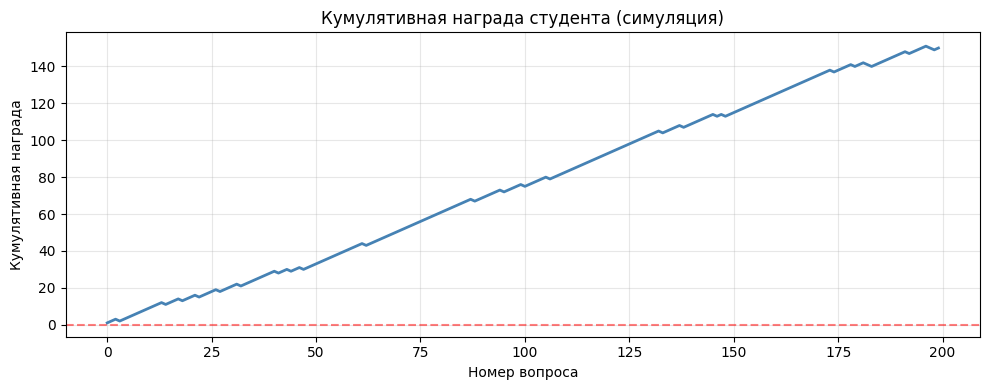

Финальная кумулятивная награда: 150
Процент правильных: 87.5%


In [15]:
def simulate_student(q_table, n_questions=100):
    states_list = list(q_table.keys())
    if len(states_list) == 0:
        return [], []
    
    rewards = []
    cumulative = []
    total = 0
    
    for i in range(n_questions):
        state = states_list[np.random.randint(len(states_list))]
        action = np.argmax(q_table[state])
        
        q_val = q_table[state][action]
        prob_correct = 1 / (1 + np.exp(-q_val))
        
        if np.random.random() < prob_correct:
            reward = 1
        else:
            reward = -1
        
        total += reward
        rewards.append(reward)
        cumulative.append(total)
    
    return rewards, cumulative

rewards_sim, cumulative_sim = simulate_student(Q, n_questions=200)

plt.figure(figsize=(10, 4))
plt.plot(cumulative_sim, color="steelblue", linewidth=2)
plt.title("Кумулятивная награда студента (симуляция)")
plt.xlabel("Номер вопроса")
plt.ylabel("Кумулятивная награда")
plt.axhline(y=0, color="red", linestyle="--", alpha=0.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Финальная кумулятивная награда: {cumulative_sim[-1]}")
print(f"Процент правильных: {(sum(1 for r in rewards_sim if r > 0) / len(rewards_sim))*100:.1f}%")

Кривая идёт вверх значит студент становится лучше.
Если линия выше нуля значит правильных ответов больше.
Наклон показывает скорость обучения. Круче вверх значит быстрее учится.

В ходе работы были реализованы методы Q-Learning и Policy Gradient для задачи предсказания ответов студентов, причём Q-Learning показал лучшую точность (57% против 55%), но оба уступили Random Forest (62%), что демонстрирует ограниченность RL на статических табличных данных.